In [31]:
%pip install seaborn
%pip install scikit-learn
%pip install dash
import seaborn as sns
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import dash
from dash import html, dcc
from dash.dependencies import Input, Output
import plotly.express as px


print("Libraries installed successfully!")

df = pd.read_csv("failures_datan.csv", low_memory=False)

# Standardize column names
df.columns = df.columns.str.lower().str.strip()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries installed successfully!



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
df.head(5)

,bankno,bidcity,bidname,bidstate,brdate,bstatus,cert,chclass,chclass1,city,...,ptrdate,qbfasset,qbfdep,resdate,restype,restype1,savr,termi,uninsdep,url
0,NaN,0,0,0,NaN,NaN,NaN,NM,NM,EAST PEORIA,...,0,374.0,238.0,NaN,FAILURE,PO,FDIC,NaN,NaN,NaN
1,NaN,0,0,0,NaN,NaN,NaN,NM,NM,GRANTWOOD,...,0,2305.0,590.0,NaN,FAILURE,PO,FDIC,NaN,NaN,NaN
2,NaN,0,0,0,NaN,NaN,NaN,NM,NM,CUMMINGS,...,0,NaN,30.0,NaN,FAILURE,P&A,FDIC,NaN,NaN,NaN
3,NaN,LINCOLN,UNION BANK&TRUST CO,NE,NaN,I,13797.0,NM,NM,TAYLOR,...,0,14542.0,13360.0,5/31/1985,FAILURE,PA,FDIC,T,NaN,na
4,NaN,0,0,0,NaN,I,18388.0,NM,NM,FAIRFIELD,...,0,6795.0,6034.0,5/31/1985,FAILURE,PO,FDIC,T,NaN,na


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4114 entries, 0 to 4113
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bankno              747 non-null    float64
 1   bidcity             4114 non-null   str    
 2   bidname             4114 non-null   str    
 3   bidstate            3873 non-null   str    
 4   brdate              930 non-null    str    
 5   bstatus             2903 non-null   str    
 6   cert                3626 non-null   float64
 7   chclass             4114 non-null   str    
 8   chclass1            4114 non-null   str    
 9   city                4114 non-null   str    
 10  cityst              4114 non-null   str    
 11  closcd              2656 non-null   str    
 12  comments            75 non-null     str    
 13  cost                3476 non-null   float64
 14  costmostrecentasof  3551 non-null   str    
 15  faildate            4114 non-null   str    
 16  failyr           

In [34]:
df.shape

(4114, 33)

In [35]:
c = df.isnull().sum()
print(c)

bankno                3367
bidcity                  0
bidname                  0
bidstate               241
brdate                3184
bstatus               1211
cert                   488
chclass                  0
chclass1                 0
city                     0
cityst                   0
closcd                1458
comments              4039
cost                   638
costmostrecentasof     563
faildate                 0
failyr                   0
fin                      0
fsl_prog              3922
fund                     0
id                       0
name                     0
pstalp                   0
ptrdate                  0
qbfasset               154
qbfdep                   2
resdate                583
restype                  0
restype1                 0
savr                     0
termi                 1461
uninsdep              3947
url                    499
dtype: int64


In [36]:
cols = ["cost", "qbfasset", "qbfdep", "uninsdep"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [37]:
# Convert Dates
df["faildate"] = pd.to_datetime(df["faildate"])

df["faildate"] = df["faildate"].dt.year

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
# Create Era
def classify_era(year):
    if year < 1980:
        return "Historical"
    elif year < 2000:
        return "S&L Crisis Era"
    elif year < 2015:
        return "Modern Crisis Era"
    else:
        return "Recent Era"


df["era"] = df["failyr"].apply(classify_era)

In [40]:
# To reduce skewness in cost and asset and improve visualization
df["log_cost"] = np.log1p(df["cost"])
df["log_asset"] = np.log1p(df["qbfasset"])

c:\Users\Rohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [41]:
# Statistics
df[["cost", "qbfasset", "qbfdep", "uninsdep"]].describe()

,cost,qbfasset,qbfdep,uninsdep
count,3.476000e+03,3.960000e+03,4.112000e+03,167.000000
mean,8.463684e+04,1.366029e+06,7.526654e+05,4801.880240
std,5.264909e+05,3.127343e+07,1.620112e+07,11897.867376
min,-1.138100e+04,1.400000e+01,0.000000e+00,1.000000
25%,3.151500e+03,1.801125e+04,1.464375e+04,131.500000
50%,1.131500e+04,5.563150e+04,4.958600e+04,633.000000
75%,4.290175e+04,1.976018e+05,1.751820e+05,3677.000000
max,1.895962e+07,1.471631e+09,9.546776e+08,95318.000000


In [42]:
# Failure Cost by Bank Type
df.groupby("chclass")["cost"].mean()

chclass
MI    150496.666667
N      33358.378303
NM     52949.692308
SB    110168.636364
SI     99346.057143
SL    136426.732177
SM    141305.770492
Name: cost, dtype: float64

In [43]:
# Failure Cost by State
df.groupby("bidstate")["cost"].sum()

bidstate
0     10349463.0
AK      835036.0
AL     1373732.0
AR     2982773.0
AZ     3637660.0
CA    34572513.0
CO     2045605.0
CT     2476479.0
DC      367027.0
DE      396124.0
FL    13172253.0
GA     5338277.0
GU        8825.0
HI        8786.0
IA      894453.0
ID      141765.0
IL     7573081.0
IN      327500.0
KS     1171532.0
KY      519321.0
LA     4680387.0
MA     3282923.0
MD      235633.0
ME      213470.0
MI     1174071.0
MN     2223774.0
MO     5569092.0
MS     2169988.0
MT       49409.0
N         5425.0
NB       25614.0
NC    24594880.0
ND      289734.0
NE     1972477.0
NH     1006093.0
NJ     1450070.0
NM      938782.0
NV      788661.0
NY     7428466.0
OH    21737882.0
OK     3052393.0
OR      809916.0
PA     2208087.0
PR     4654081.0
RI      212245.0
SC     2458475.0
SD       69523.0
TN     1177733.0
TX    71814532.0
UT      413613.0
VA     2287992.0
VT       36597.0
WA     1835728.0
WI      387078.0
WV      757287.0
WY      373268.0
Name: cost, dtype: float64

In [44]:
# Failure by Time

df.groupby("failyr")["cost"].sum()

failyr
1934           0.0
1935           0.0
1936           0.0
1937           0.0
1938           0.0
           ...    
2020       90007.0
2023    34771203.0
2024      767206.0
2025       53744.0
2026           0.0
Name: cost, Length: 88, dtype: float64

Text(0.5, 1.0, 'Average Failure Cost by Bank Type')

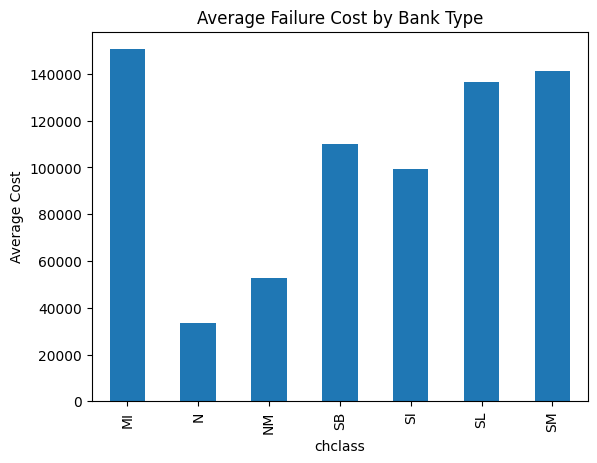

In [45]:
# Average Cost by Bank Type
avg_cost = df.groupby("chclass")["cost"].mean()

avg_cost.plot(kind="bar")
plt.ylabel("Average Cost")
plt.title("Average Failure Cost by Bank Type")

Text(0.5, 1.0, 'Bank Failure Cost Over Time')

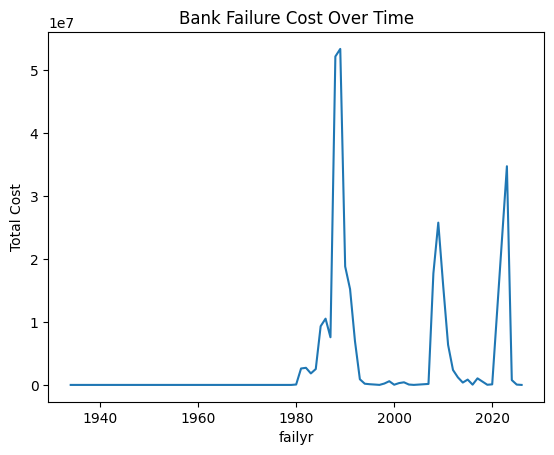

In [46]:
# Failure cost over years
yearly = df.groupby("failyr")["cost"].sum()

yearly.plot(kind="line")
plt.ylabel("Total Cost")
plt.title("Bank Failure Cost Over Time")

Text(0.5, 1.0, 'Distribution of Resolution Types')

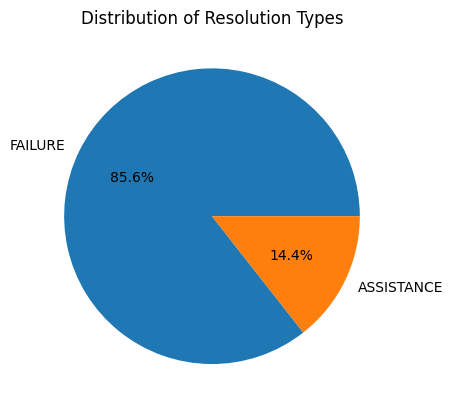

In [47]:
# Distribution of Resolution Types
df["restype"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Resolution Types")

Text(0.5, 1.0, 'Distribution of Bank Assets')

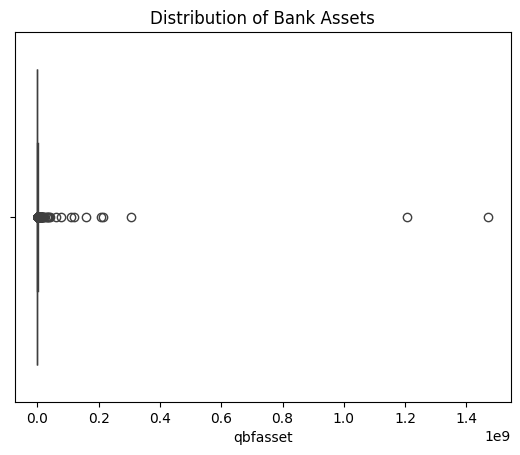

In [48]:
# Spread of Bank Asset
sns.boxplot(x=df["qbfasset"])
plt.title("Distribution of Bank Assets")

Text(0.5, 1.0, 'Assets vs Failure Cost')

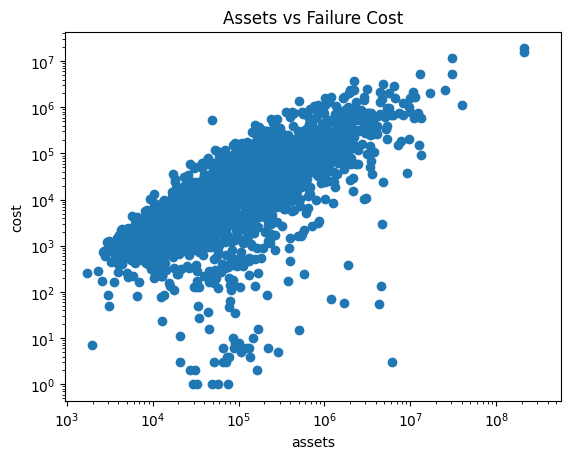

In [49]:
# Scatter plot Asset vs Cost
plt.scatter(df["qbfasset"], df["cost"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("assets")
plt.ylabel("cost")
plt.title("Assets vs Failure Cost")

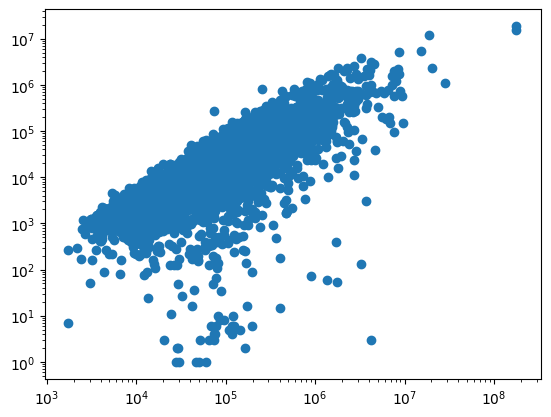

In [50]:
# Scatter plot deposit vs cost
plt.scatter(df["qbfdep"], df["cost"])
plt.xscale("log")
plt.yscale("log")

<Axes: >

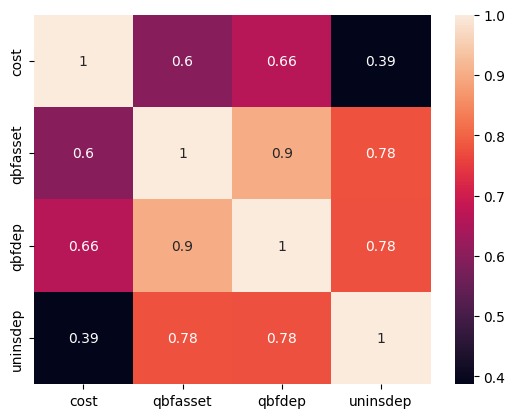

In [51]:
# Relationship Analysis
corr = df[["cost", "qbfasset", "qbfdep", "uninsdep"]].corr()
sns.heatmap(corr, annot=True)

In [52]:
app = dash.Dash(__name__)

app.layout = html.Div([html.H1( "Bank Failure Cost Analysis Dashboard",
             style={'textAlign': 'center'} ),
# ========================= # FILTERS # ========================= 
             html.Div([ html.Label("Select Year"),
                        dcc.Dropdown( id='year_dropdown',
                        options=[ {'label': str(year), 'value': year} for year in sorted(df['failyr'].dropna().unique()) ],
                        value=df['failyr'].dropna().unique()[0],
                        clearable=False ) ],
                        style={'width': '30%', 'margin': 'auto'}),
                        html.Br(),
                        # ========================= # KPI CARDS # =========================
            html.Div(id='kpi_cards'),
            html.Br(), 
# ========================= # CHARTS # =========================
            dcc.Graph(id='bar_chart'),
            dcc.Graph(id='line_chart'),
            dcc.Graph(id='pie_chart'),
            dcc.Graph(id='box_plot'),
            dcc.Graph(id='scatter_plot'),
        ])
# ========================================= # CALLBACK # =========================================

@app.callback(
[ Output('kpi_cards', 'children'),
  Output('bar_chart', 'figure'),
  Output('line_chart', 'figure'), 
  Output('pie_chart', 'figure'),
  Output('box_plot', 'figure'),
  Output('scatter_plot', 'figure')
],

[Input('year_dropdown', 'value')])

 # ========================================= # CALLBACK # =========================================

@app.callback(
[ Output('kpi_cards', 'children'),
  Output('bar_chart', 'figure'),
  Output('line_chart', 'figure'), 
  Output('pie_chart', 'figure'),
  Output('box_plot', 'figure'),
  Output('scatter_plot', 'figure')
],

[Input('year_dropdown', 'value')])
def update_dashboard(selected_year):

    filtered_df = df[df['failyr'] == selected_year]

    # =====================================
    # KPI VALUES
    # =====================================

    total_cost = filtered_df['cost'].sum()
    avg_cost = filtered_df['cost'].mean()
    total_banks = filtered_df['cert'].nunique()
    max_asset = filtered_df['qbfasset'].max()

    kpi_cards = html.Div([

        html.Div([
            html.H3("Total Failure Cost"),
            html.H4(f"${total_cost:,.0f}")
        ], style={
            'border': '1px solid black',
            'padding': '20px',
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center'
        }),

        html.Div([
            html.H3("Average Cost"),
            html.H4(f"${avg_cost:,.0f}")
        ], style={
            'border': '1px solid black',
            'padding': '20px',
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center'
        }),

        html.Div([
            html.H3("Failed Banks"),
            html.H4(f"{total_banks}")
        ], style={
            'border': '1px solid black',
            'padding': '20px',
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center'
        }),

        html.Div([
            html.H3("Largest Asset"),
            html.H4(f"${max_asset:,.0f}")
        ], style={
            'border': '1px solid black',
            'padding': '20px',
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center'
        })

    ], style={
        'display': 'flex',
        'justifyContent': 'space-around'
    })

    # =====================================
    # BAR CHART
    # =====================================

    bar_data = filtered_df.groupby('chclass')['cost'].mean().reset_index()

    bar_fig = px.bar(
        bar_data,
        x='chclass',
        y='cost',
        title='Average Failure Cost by Bank Type'
    )

    # =====================================
    # LINE CHART
    # =====================================

    yearly_data = df.groupby('failyr')['cost'].sum().reset_index()

    line_fig = px.line(
        yearly_data,
        x='failyr',
        y='cost',
        title='Bank Failure Cost Over Time'
    )

    # =====================================
    # PIE CHART
    # =====================================

    pie_fig = px.pie(
        filtered_df,
        names='restype',
        title='Resolution Type Distribution'
    )

    # =====================================
    # BOX PLOT
    # =====================================

    box_fig = px.box(
        filtered_df,
        y='log_cost',
        title='Spread of Failure Costs (Log Scale)'
    )

    # =====================================
    # SCATTER PLOT
    # =====================================

    scatter_fig = px.scatter(
        filtered_df,
        x='log_asset',
        y='log_cost',
        color='chclass',
        hover_data=['name'],
        title='Assets vs Failure Cost'
    )

    return (
        kpi_cards,
        bar_fig,
        line_fig,
        pie_fig,
        box_fig,
        scatter_fig
    )
# RUN APP # 
    if __name__ == '__main__': 
        app.run_server(debug=True)

